# Portfolio Opdracht 3: 

# 1. Inleiding

Voor deze opdracht zijn we aangenomen als AI engineers bij VisionWear AI, dit is een technologisch bedrijf dat AI ontwikkeld voor de mode industrie. VisionWear AI werkt samen met webshops, modehuizen en online kleidingplatforms en ontwikkeld hiervoor AI systemen die kleding automatisch kunnen herkennen, beschrijven en nieuwe ontwerpen genereren.

Onze opdracht is om een AI systeem te bouwen dat de volgende dingen kan:

- Kledingstukken automatisch detecteren in afbeeldingen
- Productbeschrijvingen Genereren
- Nieuwe kledingafbeeldingen genereren op basis van tekstuele beschrijvingen. 

VisionWear AI heeft hiervoor een grote dataset verzameld met modefoto's, labels en beschrijvingen, en wij gaan die gebruiken voor de bovenstaande opdracht. We gaan dit doen in 3 delen.
1. Trainen van een model om de kledingstukken en accessoires te identificeren in afbeeldingen.
2. Trainen van een model dat tekstbijschriften te genereren om de kledingstukken te beschrijven.
3. Trainen van een model dat op basis van tekstbijschriften afbeeldingen kan genereren die de kledingstukken beschrijven (met modetermen).

De tekst uit deze opdracht wordt in het engels gegenereerd.

# Setup en Data Inladen

In [1]:
import os

# Voor een stabiele config van cuda en pytorch,
# gebruik ik deze environment variables om problemen 
# met cuda libraries en log levels te voorkomen.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Dank aan deze stackoverflow post die uitlegde ik fatsoenlijk mn cuda libraries moest linken,
# BRON: https://stackoverflow.com/questions/13428910/how-to-set-the-environment-variable-ld-library-path-in-linux 
os.environ['LD_LIBRARY_PATH'] = '/usr/lib:/opt/cuda/targets/x86_64-linux/lib'

import torch
import nlpaug.augmenter.word as naw


# Zet cuDNN benchmarking en determinisme tijdelijk zo dat hij de mismatch negeert
#torch.backends.cudnn.benchmark = False
#torch.backends.cudnn.deterministic = True


from transformers import (
    pipeline, 
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    AutoConfig,
    DataCollatorWithPadding,
    AutoModelForMaskedLM
)

print(f"Pytorch CUDA beschikbaar: {torch.cuda.is_available()}")

Pytorch CUDA beschikbaar: True


In [2]:
# Inladen van libraries
# iets in de volgorde zorgt ervoor dat er geen problemen zijn met cuda libraries,
# dus laat de volgorde zo staan AUB.
import cv2
import os
import re
import gc
import random
import time
from pathlib import Path
from collections import Counter
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack

from matplotlib import patches

from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model

from datasets import Dataset

from torchview import draw_graph 

I0000 00:00:1780684777.992899   48964 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780684779.296505   48964 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# En stellen hier een random state variable in, hierdoor blijven onze splits, 
# maar ook de modellering die daarbij komt kijken consistent met een set seed.
def set_seeds(seed=65):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # Voor volledige GPU determinisme (waarschuwing: kan training vertragen)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seeds(65)

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)

In [ ]:
import os, yaml, shutil, cv2
from pathlib import Path
from ultralytics import YOLO

import os, yaml, shutil, cv2
from pathlib import Path
from ultralytics import YOLO

# 1. PADEN DEFINIËREN
DATA_DIR = Path("/home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3")
ORIGINAL_IMAGES = DATA_DIR / "Train/images"
ORIGINAL_LABELS = DATA_DIR / "Train/labels"

# Maak mappen aan



In [ ]:
BASE_DIR = Path.cwd()

TRAIN_DIR = BASE_DIR / "Train"
TEST_DIR = BASE_DIR / "Test"

train_images_dir = TRAIN_DIR / "images"
train_labels_dir = TRAIN_DIR / "labels"

test_images_dir = TEST_DIR / "images"




BASE_PROJECT_DIR = Path("/home/beef/Downloads/models_run")

(BASE_PROJECT_DIR / "head_dataset/images").mkdir(parents=True, exist_ok=True)
(BASE_PROJECT_DIR / "head_dataset/labels").mkdir(parents=True, exist_ok=True)
(BASE_PROJECT_DIR / "generalist_dataset/images").mkdir(parents=True, exist_ok=True)
(BASE_PROJECT_DIR / "generalist_dataset/labels").mkdir(parents=True, exist_ok=True)

In [5]:

parsed_data = []

for img_path in train_images_dir.glob("*"):
    if img_path.suffix.lower() not in [".jpg"]:
        continue

    label_path = train_labels_dir / f"{img_path.stem}.txt"

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        
        parts = line.strip().split()
        if len(parts) == 5:
            parsed_data.append(
                {
                    "image_path": str(img_path),
                    "label_path": str(label_path),
                    "image_name": img_path.name,
                    "class_id": int(parts[0]),
                    "center_x": float(parts[1]),
                    "center_y": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4]),
                }
            )

# Maak het DataFrame aan
train_df = pd.DataFrame(parsed_data)
display(train_df.head(1))

,image_path,label_path,image_name,class_id,center_x,center_y,width,height
0,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,1.jpg,8,0.68875,0.639167,0.3025,0.118333


In [6]:
def check_dataset(df, label):
    """
    Print informatie over het DataFrame en de bijbehorende Wav-bestanden,
    zoals het aantal records, ontbrekende waarden en het aantal Wav-bestanden in de directory.

    Args:
        df (pd.DataFrame): Het DataFrame met de kolom 

    Returns:
        Een overzicht van de dataset, inclusief het aantal records, ontbrekende waarden en het aantal Wav-bestanden.
    """

    display(df.head(1))
    print(f"{label.lower()}_df shape = {df.shape}")
    
    # We gebruiken rglob om recurively door de files te kijken
    # hierdoor hoeven we niet specifiek te kijken voor genre mappen
    # en meer robuust voor het geval een files is misplaced

    print("\nOntbrekende waarden in dataframe:")
    print(df.isna().sum())

In [7]:
print(f"Dimensies van het DataFrame: {train_df.shape}")

amount_imgs = train_df["image_name"].nunique()
print("Aantal unieke afbeeldingen:", amount_imgs)
check_dataset(train_df, "Train")

Dimensies van het DataFrame: (8298, 8)
Aantal unieke afbeeldingen: 2145


,image_path,label_path,image_name,class_id,center_x,center_y,width,height
0,/home/beef/Downloads/karaoke-k-klassificatie-2...,/home/beef/Downloads/karaoke-k-klassificatie-2...,1.jpg,8,0.68875,0.639167,0.3025,0.118333


train_df shape = (8298, 8)

Ontbrekende waarden in dataframe:
image_path    0
label_path    0
image_name    0
class_id      0
center_x      0
center_y      0
width         0
height        0
dtype: int64


Train_DF en Train Wav Files:
- train_df shape = (8298, 8)
- Aantal train image files op schijf: 2145

| Kolomnaam | Uitleg | 
| -| -|
| image_path| Bevat het pad naar de image file | 
|label_path | Bevat het pad naar het txtbestand met de afmetingen voor de image | 
| image_name| Bevat de naam van het corresponderende image file | 
| class_id| Bevat de numerieke categorie van het clothing item|
| center_x| Bevat het centrale x coordinaat van de bounding box |
| center_y| Bevat het centrale y coordinaat van de bounding box|
| width| Bevat de breedte van de bounding box|
| height| Bevat de hoogte van de bounding box|



# 2. EDA

eda uitleg

In [8]:
# Hier hebben we vaste kleuren ingesteld voor de kledingsstukken, 
# zodat alles consistent blijft qua overzicht en graphics.
clothing_colors = {
    'sunglass': "#ff0000",  
    'hat': "#ff7b00",
    'jacket': "#a29a00", # keb geel donkerder gemaakt, anders was de witte txt niet te zien
    'shirt': "#b7ff00",  
    'pants': "#00FF6A",   
    'shorts': "#00ffe5",  
    'skirt': "#0000ff",     
    'dress': "#6f00ff",
    'bag': "#d400ff", 
    'shoe': "#ff0090"}

# En hier hebben we een mapping van class_id's naar labels, 
# zodat we makkelijk kunnen zien welke class_id bij welk kledingstuk hoort.
clothing_labels = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",
}

# Dan linken we de class_id's aan de class_names, 
# zodat we makkelijk kunnen zien welke class_id bij welk kledingstuk hoort.
train_df['class_name'] = train_df['class_id'].map(clothing_labels)

## 2.1. Aantal Kledingstukken per Foto

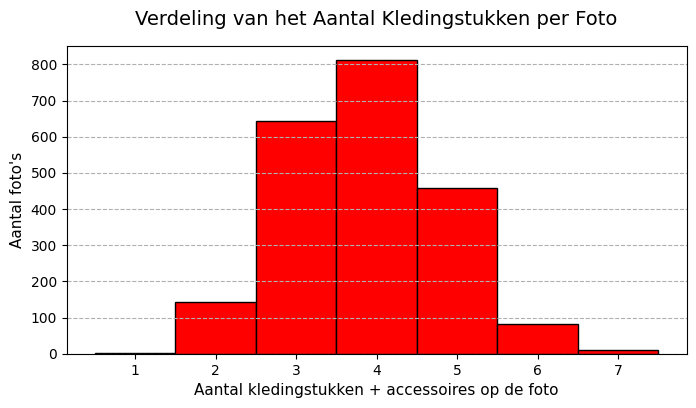

In [9]:
# We beginnen met een simpele analyse van de dataset, 
# namelijk de verdeling van het aantal kledingstukken per foto.
df_summary = train_df.groupby('image_name').agg(totaal_tags=('class_id', 'count')).reset_index()

# De min en max
max_stukken = df_summary['totaal_tags'].max()
min_stukken = df_summary['totaal_tags'].min()


# En dan een simpele barchart voor de eerste visual
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_summary, 
    x='totaal_tags', 
    discrete=True, 
    color="#ff0000", 
    alpha=1)

plt.title('Verdeling van het Aantal Kledingstukken per Foto', fontsize=14, pad=15)
plt.xlabel('Aantal kledingstukken + accessoires op de foto', fontsize=11)
plt.ylabel('Aantal foto\'s', fontsize=11)
plt.xticks(range(int(min_stukken), int(max_stukken) + 1))
plt.grid(axis='y', linestyle='--', alpha=1)

plt.show()

**Analyse:**

We zijn begonnen naar het aantal kledingstukken die voorkomen per foto.

Hierboven zien we die dus, we zien hier vrij vreemds. De meeste foto's hebben tussen de 3 en 5 kledingstukken, en zoals later gezien wordt zijn niet alle kledingstukken gelabeld dus dit leidt verder niet tot nieuwe inzichten.

## 2.2. Aantal Kledingssoorten Aanwezigheid

We gaan hieronder verder met de analyse door te kijken naar de aanwezigheid van alle kledingstukken, dat gaan we hieronder nogmaals doen met een simpele barchart.

shoe        : 2081
shirt       : 1486
bag         : 1188
jacket      : 777
skirt       : 697
dress       : 550
pants       : 508
shorts      : 395
sunglass    : 343
hat         : 273


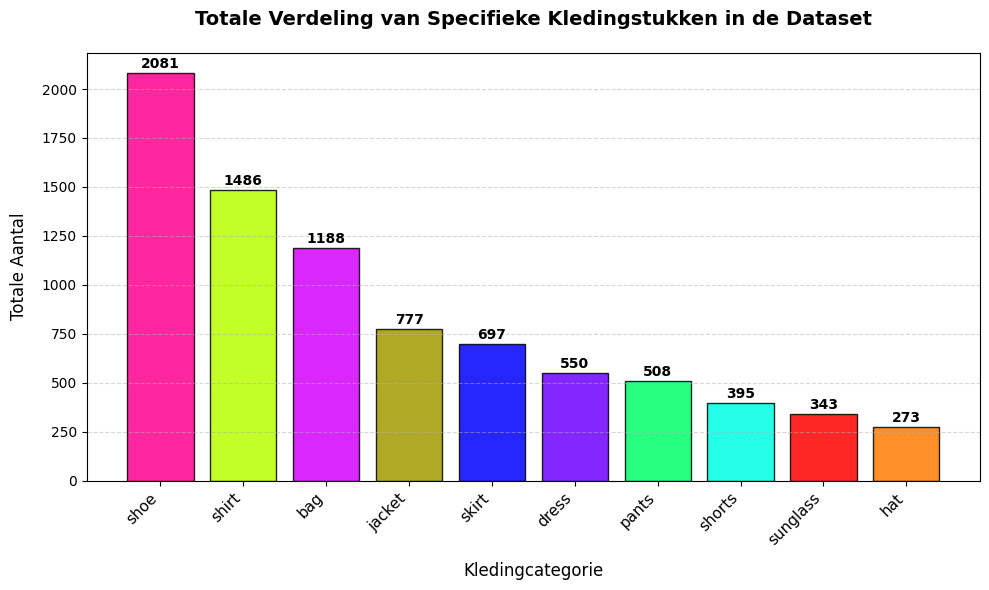

In [10]:
# Nu gaan we kijken naar de verdeling van de specifieke kledingstukken in de dataset,
# Hierbij kijken we gewoon naar value counts en plotten deze 
counts = train_df['class_name'].value_counts()

for name in counts.index:
    print(f"{name.ljust(12)}: {str(counts[name])}")


plot_colors = [clothing_colors.get(name, "#333333") for name in counts.index]

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index, counts.values, color=plot_colors, edgecolor='black', alpha=0.85)


for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        f'{int(yval)}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Totale Verdeling van Specifieke Kledingstukken in de Dataset', fontsize=14, pad=20, weight='bold')
plt.xlabel('Kledingcategorie', fontsize=12, labelpad=10)
plt.ylabel('Totale Aantal', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Analyse:**

Zoals we hierboven zien zijn de verschillende kledingstukken en accessoires niet gelijk verdeeld over de dataset. We zien dat schoenen veruit het meest voorkomen, maar dit is ook logisch aangezien er van de overige categorieen geen alternatief is voor shoes, bevalve barefoot maar dat is geen categorie.

Verder zien we ook dat van de accesoiries dat bag veruit het meest voorkomt, daarna pas sunglasses en hats. 

Maar dit geeft uiteindelijk een oneerlijk beeld van de representatie van de kledingstukken, daarom gaan we het hieronder groeperen.

### 2.2.1. Kledinstukken Gegroepeerd op Categorie

Hieronder gaan we dus nogmaals de verdelingen plotten, maar deze keer groeperen we ze op de algemene plek op het lichaam waar ze horen.

In [11]:
# We groeperen de kledingstukken in hoofdgroepen, 
# zodat we een beter overzicht krijgen van de verdeling 
# van de verschillende soorten kledingstukken.
# Dress hebben we hier zometeen dubbel omdat het functioneert als legs als torso.
hoofdgroepen_mapping = {
    'pants': 'Legwear',
    'shorts': 'Legwear',
    'skirt': 'Legwear',
    'shirt': 'Torsokleding',
    'bag': 'Accessoires',
    'sunglass': 'Accessoires',
    'hat': 'Accessoires',
    'shoe': 'Footwear',
    'jacket': 'Outerwear'}

# Copy make voor edits
plot_df = train_df.copy()

# Dan linken we de hoofdgroepen aan de class_names
plot_df['hoofdgroep'] = plot_df['class_name'].map(hoofdgroepen_mapping).fillna('Overig')

# En dresses dubbel
dresses = plot_df[plot_df['class_name'] == 'dress'].copy()

# En dan alles toevoegen aan een df
if not dresses.empty:
    dresses_torso = dresses.copy()
    dresses_torso['hoofdgroep'] = 'Torsokleding'
    
    dresses_legwear = dresses.copy()
    dresses_legwear['hoofdgroep'] = 'Legwear'
    
    plot_df = plot_df[plot_df['class_name'] != 'dress']
    
    plot_df = pd.concat([plot_df, dresses_torso, dresses_legwear], ignore_index=True)

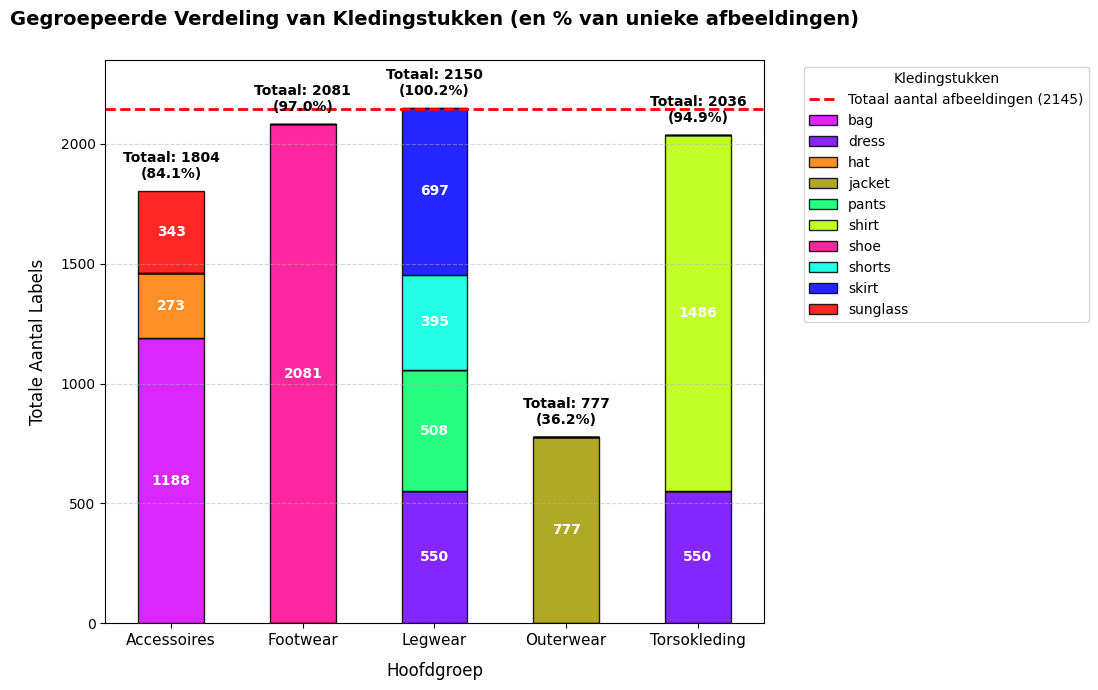

In [12]:
# Dan gaan we hier de verdeling van de hoofdgroepen plotten,
grouped_data = pd.crosstab(plot_df['hoofdgroep'], plot_df['class_name'])
current_columns = grouped_data.columns

# en hier halen we de kleuren op voor de huidige class_names
plot_colors = [clothing_colors.get(name, "#333333") for name in current_columns]


fig, ax = plt.subplots(figsize=(11, 7))  
grouped_data.plot(kind='bar', stacked=True, color=plot_colors, edgecolor='black', alpha=0.85, ax=ax)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(
            x + width/2, 
            y + height/2,  
            f'{int(height)}', 
            ha='center', 
            va='center', 
            fontsize=10, 
            weight='bold',
            color='white'  
        )

# Nog een rode lijn voor het totaal aantal afbeeldingen, 
# zodat we kunnen zien hoeveel afbeeldingen er zijn in vergelijking met het aantal labels,
# per lichaamsdeel
ax.axhline(
    y=amount_imgs, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Totaal aantal afbeeldingen ({amount_imgs})' )

# En hier voegen we de totale aantallen en percentages toe boven elke bar,
# zodat we kunnen zien hoeveel labels er zijn per hoofdgroep,
for i, total in enumerate(grouped_data.sum(axis=1)):
    percentage = (total / amount_imgs) * 100
    
    ax.text(
        i, 
        total + (grouped_data.values.max() * 0.02),  
        f'Totaal: {int(total)}\n({percentage:.1f}%)', 
        ha='center', 
        va='bottom', 
        weight='bold', 
        fontsize=10)
    
plt.title('Gegroepeerde Verdeling van Kledingstukken (en % van unieke afbeeldingen)', fontsize=14, pad=25, weight='bold')
plt.ylabel('Totale Aantal Labels', fontsize=12, labelpad=10)
plt.xlabel('Hoofdgroep', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11) 

# En nog een hoger limiet voor een nette graph
ax.set_ylim(0, grouped_data.sum(axis=1).max() + 200)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Kledingstukken", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

Als we alleen zouden kijken naar de categorieen los van elkaar zien we een heel scheve verdeling, maar als we hieronder zouden kijken naar de kledingstukken gegrrpepeerd op de kledingscategorie waar ze bij behoren zien we een heel ander verhaal:

- Legwear
    - Pants
    - Shorts
    - Skirt
- Torsokleding
    - Dress
    - Shirt
- Accesseroires
    - Bag
    - Sunglasses
    - Hat
- Footwear
    - Shoes
- Outerwear
    - Jacket


We hebben hierbij ook dress bij legwear en torsokleding gezet, dresses functioneren als beide en als deze ontbrak uit een van de 2, zou dat duiden op mensen zonder broek en/of shirt.

Verder zien we dat outerwear/jacket veruit het minste is, maar ook logisch aangezien deze naast accesoires de optionele kledingstuk is.

Verder uit accessoires zien we dat bags veruit het meeste voorkomen.

Hierbij is het opvallendste de missende schoenen en om daar inzicht in te krijgen gaan we in dit volgende hoofdstuk kijken naar de image data en de boxes in de foto's.

## 2.3. Fotos

In dit deel van de EDA gaan we de images analyseren en ook de boxes binnen die images analyseren.

We beginnen hieronder met de image sizes.

In [13]:
# Voor elke image in de Train en Test directories
# lezen we de images in met OpenCV en pakken de unieke resoluties
def check_sizes(dir_path):
    return {cv2.imread(str(f)).shape[:2] for f in dir_path.glob("*.jpg")}

# En de funtie toepassen op de directories
train_sizes = check_sizes(train_images_dir)
test_sizes = check_sizes(test_images_dir)
print(f"Train formaten: {train_sizes}")
print(f"Test formaten: {test_sizes}")

Train formaten: {(600, 400)}
Test formaten: {(600, 400)}


**Analyse:**

We zien hierboven dat alle images dezelfde afmetingen hebben (600 x 400 pixels), we hoeven dus bij later modelleren alleen de verhouding van 3 tot 2 in gedachte houden, maar niet verschillende afmetingen.

### 2.3.1. Subboxes per Image

In [19]:
# Hieronder 3 aparte functies om de absolute breedte, hoogte en oppervlakte 
# van de bounding boxes te plotten
def plot_absolute_width_horizontal(df, images_dir):
    plot_df = df.copy()
    
    img_dims = {f.name: cv2.imread(str(f)).shape[1] for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    plot_df['abs_width'] = plot_df['width'] * plot_df['image_name'].map(img_dims)
    
    order = plot_df.groupby("class_name")["abs_width"].median().sort_values(ascending=False).index

    # Plotten
    plt.figure(figsize=(10, 8))
    sns.boxplot(
        data=plot_df, 
        x="abs_width", 
        y="class_name", 
        order=order, 
        palette=clothing_colors, 
        hue="class_name", 
        orient='h'
    )
    
    plt.title("Absolute Breedte per Categorie in Pixels", fontsize=14, weight='bold')
    plt.xlabel("Breedte in Pixels")
    plt.ylabel("Kledingcategorie")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()


def plot_absolute_height_vertical(df, images_dir):
    plot_df = df.copy()
    img_dims = {f.name: cv2.imread(str(f)).shape[0] for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    plot_df['abs_height'] = plot_df['height'] * plot_df['image_name'].map(img_dims)
    
    order = plot_df.groupby("class_name")["abs_height"].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="class_name", y="abs_height", order=order, 
                palette=clothing_colors, hue="class_name", legend=False)
    plt.title("Absolute Hoogte per Categorie in Pixels", fontsize=14, weight='bold')
    plt.ylabel("Hoogte in Pixels")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

def plot_absolute_area_vertical(df, images_dir):
    plot_df = df.copy()
    img_dims = {f.name: (cv2.imread(str(f)).shape[1], cv2.imread(str(f)).shape[0]) 
                for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    
    plot_df[['img_w', 'img_h']] = plot_df['image_name'].map(img_dims).tolist()
    plot_df["abs_area"] = (plot_df["width"] * plot_df["img_w"]) * (plot_df["height"] * plot_df["img_h"])
    
    order = plot_df.groupby("class_name")["abs_area"].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="class_name", y="abs_area", order=order, 
                palette=clothing_colors, hue="class_name", legend=False)
    plt.title("Totaal aantal Pixels per Categorie", fontsize=14, weight='bold')
    plt.ylabel("Oppervlakte in Pixels")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()





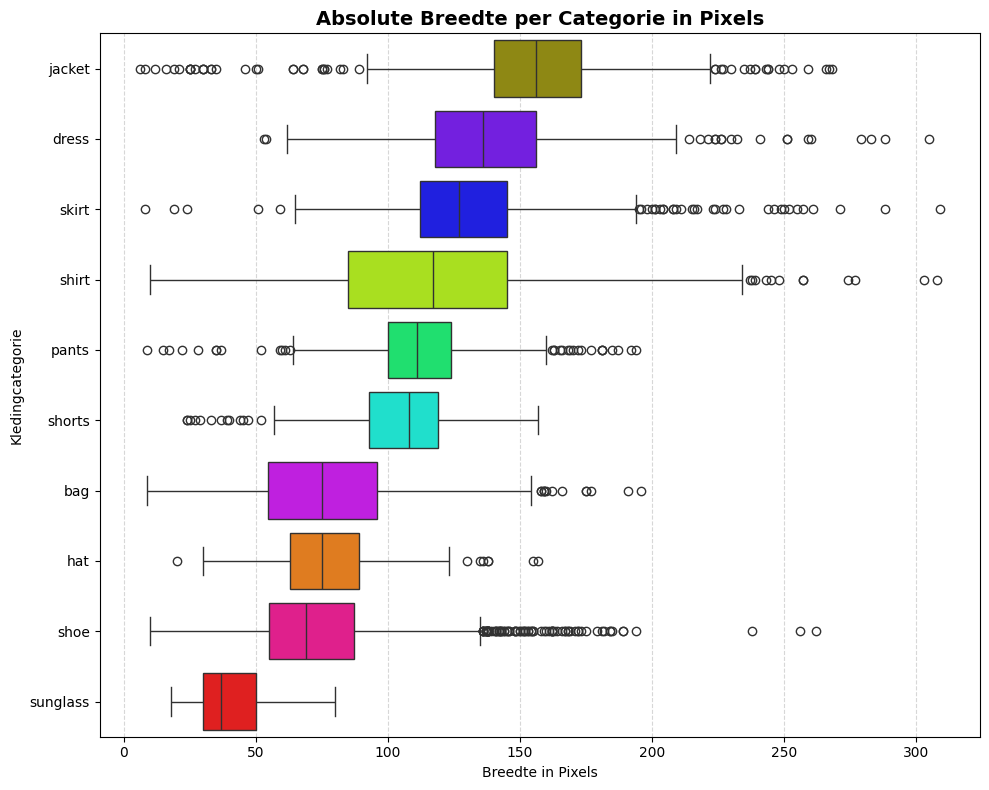

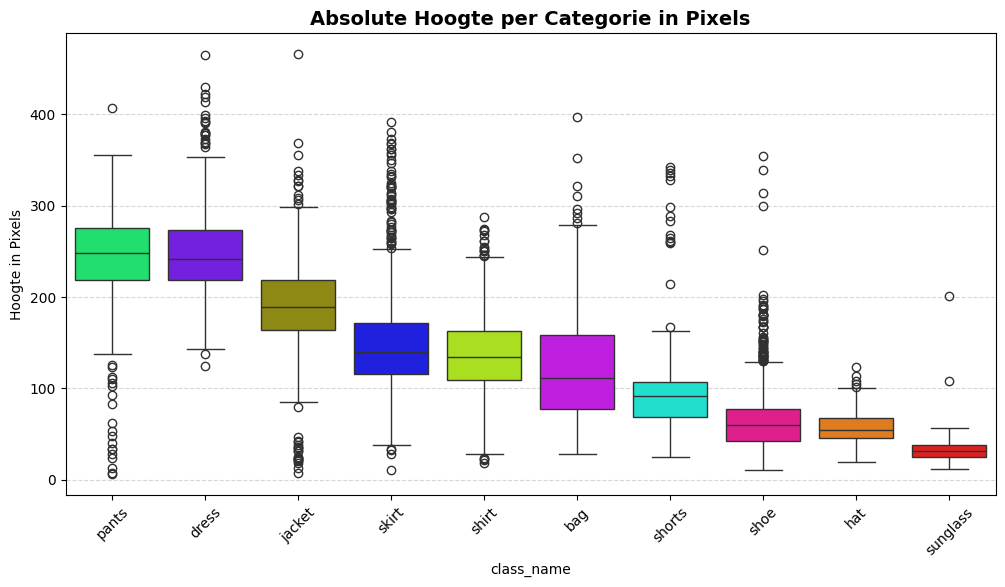

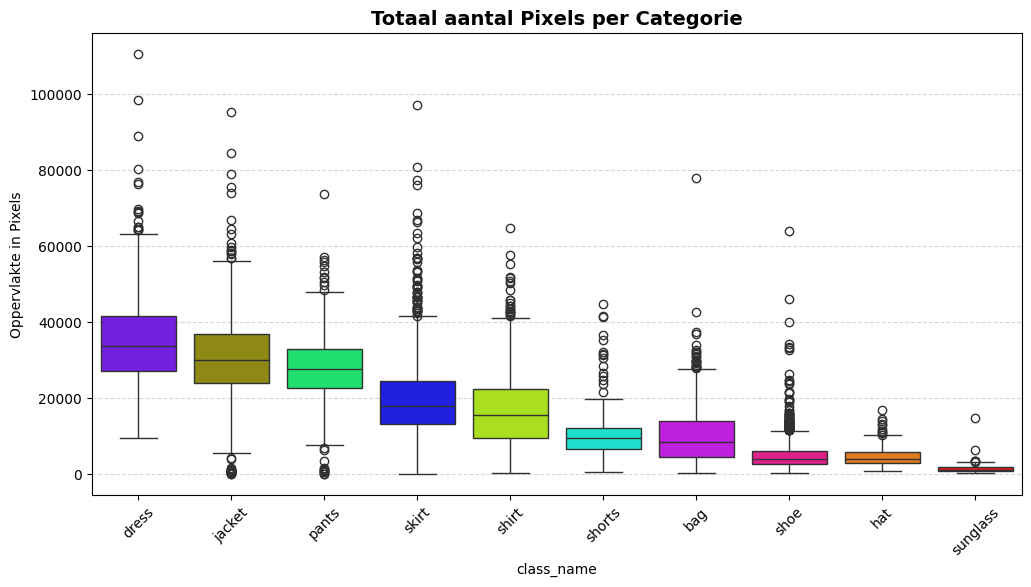

In [20]:
plot_absolute_width_horizontal(train_df, train_images_dir)
plot_absolute_height_vertical(train_df, train_images_dir)
plot_absolute_area_vertical(train_df, train_images_dir)

**Analyse:**

De belangrijkste observatie hier is het gebrek aan size van vooral hat en sunglasses. Hoewel dit ook geld voor shoes, hebben die een veel betere representatie als we terug kijken naar de aantallen.

Voor het modelleren hebben we dus hat en sunglassses apart genomen en zoals later wordt getoond had het model vooral moeite met sunglasses.


### 2.3.2. Subboxes Plotten 

In [ ]:
# Hieronder plotten we 4 random images,
# zodat we ze kunnen scannen voor anomalies.
def plot_fashion_grid(df):
    unique_images = df["image_name"].unique()
    chosen_images = np.random.choice(unique_images, size=4, replace=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()  
    
    for i, image_name in enumerate(chosen_images):
        ax = axes[i]
        
        img_objects = df[df["image_name"] == image_name]
        
        img_path = img_objects.iloc[0]['image_path']
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w, _ = image.shape
        
        ax.imshow(image)
        
        for _, row in img_objects.iterrows():
            c_name = row["class_name"]
            box_color = clothing_colors.get(c_name, "#FFFFFF")
            
            w = row["width"] * img_w
            h = row["height"] * img_h
            xmin = (row["center_x"] - row["width"] / 2) * img_w
            ymin = (row["center_y"] - row["height"] / 2) * img_h
            
            rect = patches.Rectangle(
                (xmin, ymin),
                w,
                h,
                linewidth=2.0,
                edgecolor=box_color,
                facecolor="none",
            )
            ax.add_patch(rect)
            
            text_color = "black" if c_name in ["shirt", "shorts"] else "white"
            
            ax.text(
                xmin,
                ymin - 8 if ymin - 8 > 0 else ymin + 15,  
                f" {c_name.upper()} ",
                color=text_color,
                fontsize=8,
                weight="bold",
                bbox=dict(facecolor=box_color, edgecolor=box_color, alpha=0.85, pad=1),
            )
        
        ax.set_title(f"{image_name}", fontsize=11, pad=5)
        ax.axis("off")
        
    plt.suptitle("EDA Visualisatie: 2x2 Kleding Grid", fontsize=18, weight="bold", y=0.95)
    plt.tight_layout()
    plt.show()

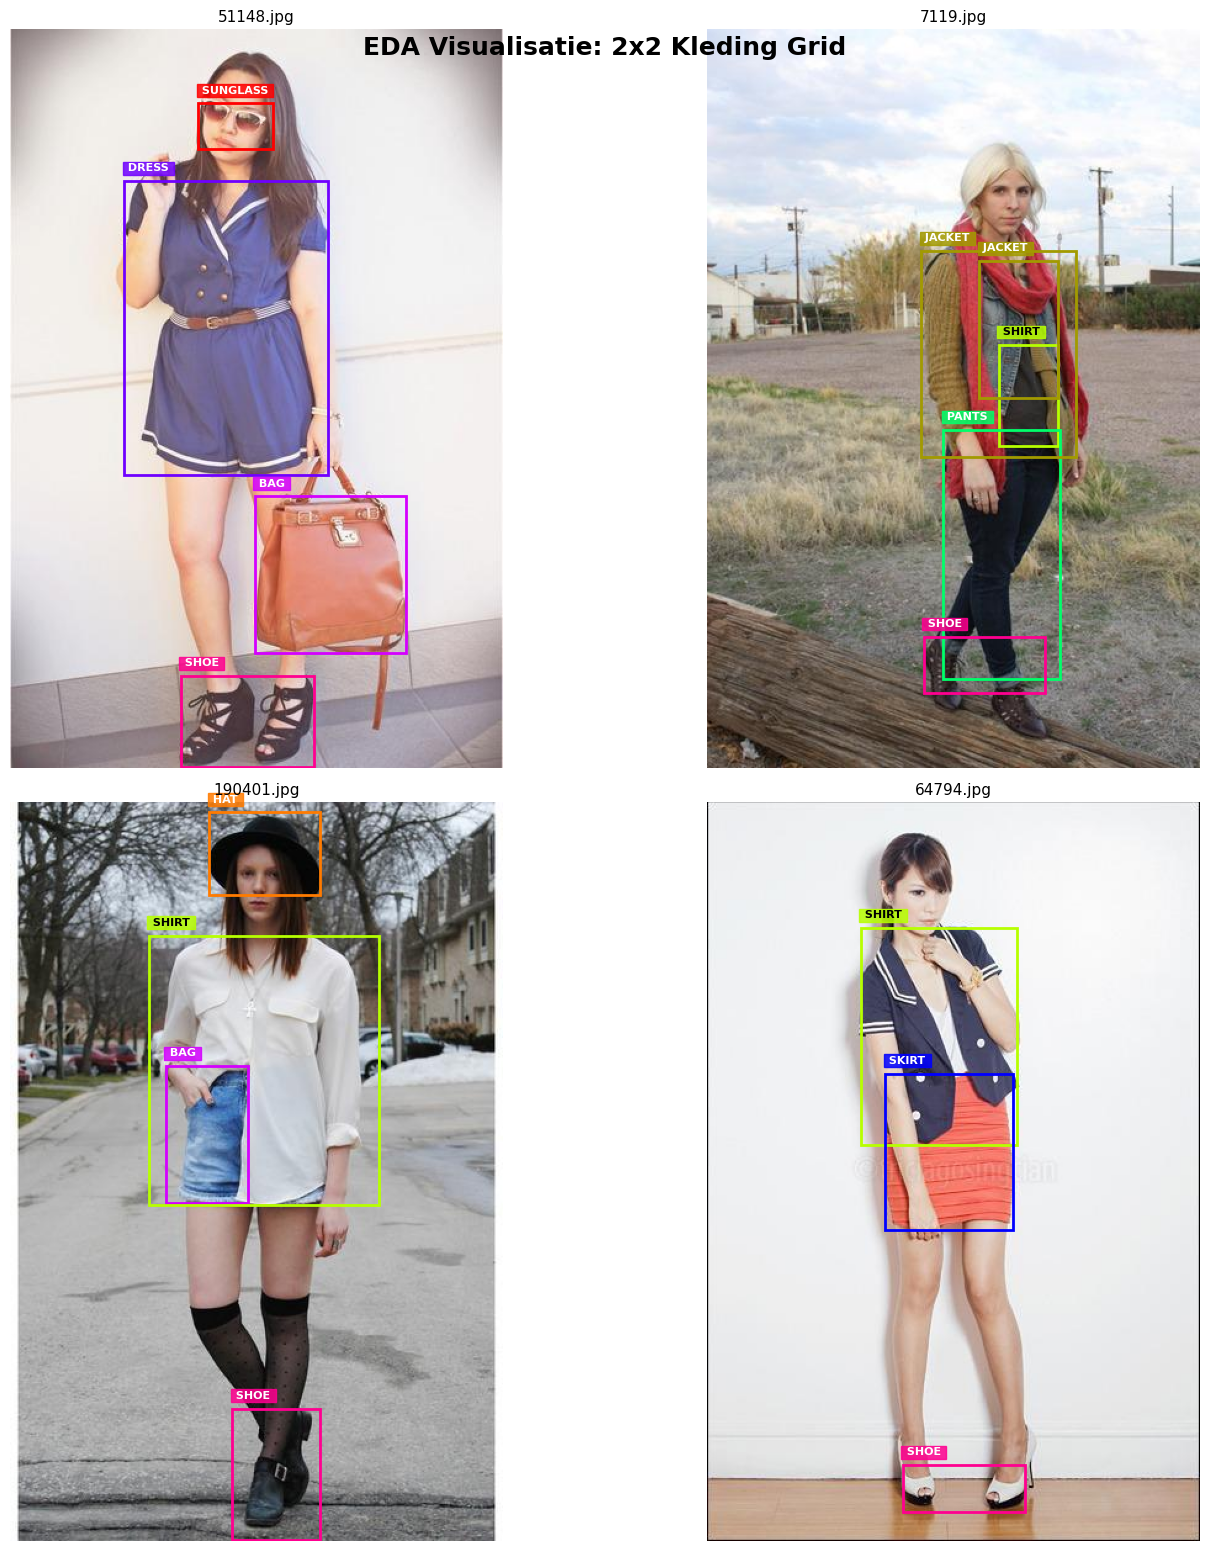

In [17]:
plot_fashion_grid(train_df)

### 2.3.3. Boxes Anomalies

Zoals hierboven dus te zien is bevatten de meeste fotos meerdere delen van de afbeeldingen die een kledingsstuk bevatten.

1. Anomalies en Fouten

Toch zagen we bij kort browsen door de images een paar anomalies zoals hieronder te zien zijn, zoals sunglasses met 1 glas en een paar mislabeled stukken clothing.

<img src="nosunglass 2.png" width="400">
<br>

<img src="nosunglass.png" width="400">
<br>

<img src="nojacket.png" width="400">
<br>

<img src="nobag.png" width="400">
<br>

2. Shoeless:

Verder zagen we dat er verassend weinig shoes waren voor wat de verwachting was. Zoals hieronder te zien waren er een paar images waar schoenen in zaten, maar geen box er om heen. Dit is uiteindelijk geen probleem want we hebben meer dan genoeg data, maar wel een observatie.

<img src="noshoes1.png" width="400">
<br>

<img src="noshoes2.png" width="400">
<br>


Ook zagen we hier een daar wat watermarks, ook door de boxes van de kledingsstukken heen, gelukkig was dit bij de random images die wij bekeken hadden heel zeldzaam, maar het is een aandachtspunt.

Het is voor ons niet mogelijk om deze te cleanen want het zijn 2145 images. Dus moeten we het model iets aan de algemenere kant houden zodat hij niet overgetraind wordt op foutieve images.


In [18]:
aaaaaa

NameError: name 'aaaaaa' is not defined

In [ ]:
def generate_datasets():
    print("🔄 Genereren van datasets (met correcte coördinaten)...")
    crop_count = 0
    
    for img_path in ORIGINAL_IMAGES.glob("*.jpg"):
        label_path = ORIGINAL_LABELS / f"{img_path.stem}.txt"
        if not label_path.exists(): continue

        img = cv2.imread(str(img_path))
        if img is None: continue
        img_h, img_w, _ = img.shape
        
        with open(label_path, "r") as f: lines = f.readlines()
        
        # Specialist (Heads)
        for line in lines:
            cls, xc, yc, w, h = map(float, line.split())
            if int(cls) in [0, 1]: # Sunglass/Hat
                # Bereken de uitsnede (crop)
                abs_w, abs_h = w * img_w, h * img_h
                size = int(max(abs_w, abs_h) * 2.5) # Iets strakker dan 3.5
                x1 = max(0, int(xc * img_w - size/2))
                y1 = max(0, int(yc * img_h - size/2))
                x2 = min(img_w, int(xc * img_w + size/2))
                y2 = min(img_h, int(yc * img_h + size/2))
                
                crop = img[y1:y2, x1:x2]
                if crop.size > 0:
                    # Bereken de nieuwe coördinaten binnen deze specifieke crop
                    # Formule: (Positie_in_origineel - Start_crop) / Breedte_crop
                    new_xc = ((xc * img_w) - x1) / (x2 - x1)
                    new_yc = ((yc * img_h) - y1) / (y2 - y1)
                    new_w = (w * img_w) / (x2 - x1)
                    new_h = (h * img_h) / (y2 - y1)
                    
                    cv2.imwrite(str(BASE_PROJECT_DIR / f"head_dataset/images/crop_{crop_count}.jpg"), crop)
                    with open(BASE_PROJECT_DIR / f"head_dataset/labels/crop_{crop_count}.txt", "w") as f:
                        f.write(f"{int(cls)} {new_xc:.6f} {new_yc:.6f} {new_w:.6f} {new_h:.6f}")
                    crop_count += 1
        
        # Generalist (Clean) kopie blijft hetzelfde
        shutil.copy(img_path, BASE_PROJECT_DIR / "generalist_dataset/images" / img_path.name)
        with open(BASE_PROJECT_DIR / "generalist_dataset/labels" / label_path.name, "w") as f:
            for line in lines:
                parts = line.split()
                if int(parts[0]) not in [0, 1]: 
                    new_id = int(parts[0]) - 2 
                    f.write(f"{new_id} {' '.join(parts[1:])}\n")

In [ ]:
if not any((BASE_PROJECT_DIR / "head_dataset/images").iterdir()):
    generate_datasets()


In [ ]:
def clear_memory():
    # 1. Verwijder modellen uit het geheugen (als ze niet meer nodig zijn)
    # Bijvoorbeeld: del model_spec
    
    # 2. Forceer garbage collection
    gc.collect()
    
    # 3. Leeg de cache van de GPU
    torch.cuda.empty_cache()
    
    # Optioneel: bekijk hoeveel VRAM er nog vrij is
    print(f"Vrij VRAM: {torch.cuda.memory_reserved(0) - torch.cuda.memory_allocated(0)} bytes")

In [ ]:
with open(BASE_PROJECT_DIR / "head_specialist.yaml", "w") as f:
    yaml.dump({"path": str(BASE_PROJECT_DIR / "head_dataset"), "train": "images", "val": "images", "nc": 2, "names": ["sunglass", "hat"]}, f)

with open(BASE_PROJECT_DIR / "generalist.yaml", "w") as f:
    yaml.dump({"path": str(BASE_PROJECT_DIR / "generalist_dataset"), "train": "images", "val": "images", "nc": 8, "names": ["jacket", "shirt", "pants", "shorts", "skirt", "dress", "bag", "shoe"]}, f)


In [ ]:

clear_memory()
model_spec = YOLO("yolo26n.pt") # Nano is perfect voor de specialist
model_spec.train(
    data=str(BASE_PROJECT_DIR / "head_specialist.yaml"), 
    epochs=100, 
    project=str(BASE_PROJECT_DIR), 
    name="spec_run", 
    imgsz=[300, 200]
)
clear_memory()

Vrij VRAM: 120473088 bytes
New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11907MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/beef/Downloads/models_run/head_specialist.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=[300, 200], int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [ ]:



clear_memory()
model_gen = YOLO("yolo26n.pt") # Medium is perfect voor de generalist
model_gen.train(
    data=str(BASE_PROJECT_DIR / "generalist.yaml"), 
    epochs=200, 
    project=str(BASE_PROJECT_DIR), 
    name="gen_run", 
    imgsz=[300, 200],
)
clear_memory()


Vrij VRAM: 116365312 bytes
New https://pypi.org/project/ultralytics/8.4.60 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11907MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/beef/Downloads/models_run/generalist.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=[300, 200], int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train,

In [ ]:
# 1. Pak automatisch de eerste afbeelding uit de map
test_images = list(DATA_DIR.glob("Train/images/*.jpg"))

if not test_images:
    print("❌ Geen afbeeldingen gevonden in de map!")
else:
    test_image_path = test_images[0] # Pak de eerste
    print(f"🔍 Testen met: {test_image_path.name}")
    
    # 2. Run de detectie
    results = combo.predict(str(test_image_path))
    
    # 3. Visualiseer
    import cv2
    img = cv2.imread(str(test_image_path))
    
    for box in results:
        # box.xyxy geeft de coördinaten [x1, y1, x2, y2]
        coords = box.xyxy[0].tolist()
        x1, y1, x2, y2 = [int(x) for x in coords]
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        
        # Teken de box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"ID: {cls_id} ({conf:.2f})"
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Sla het resultaat op
    output_path = BASE_PROJECT_DIR / "resultaat_detectie.jpg"
    cv2.imwrite(str(output_path), img)
    print(f"✅ Detectie voltooid! Bekijk resultaat in: {output_path}")

🔍 Testen met: 1.jpg
✅ Detectie voltooid! Bekijk resultaat in: /home/beef/Downloads/models_run/resultaat_detectie.jpg


In [ ]:
aaaa

# Opdracht 2: Objectdetectie
 In deze deelopdracht werk je uitsluitend met de images en labels uit de data voor
deel 1. Bouw en train een objectdetectie model om de tien klassen kleding en
modeaccessoires in de dataset te detecteren en hun locaties te voorspellen met
behulp van bounding-boxes.

 Beschrijf in je eigen woorden hoe je model voorspellingen doet.

 Beschrijf hoe je de afbeeldingen voorbewerkt.

 Beschrijf in detail welke stappen, indien aanwezig, je onderneemt voor feature
engineering.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs.

 Beschrijf de lossfunctie voor dit model in je eigen woorden en hoe deze werk

# Opdracht 4: Beeldgeneratie
 In deze deelopdracht werk je met de H&M images en captions dataset.

 Voor deze opdracht kies je een voorgetraind model van Hugging Face en fine-tune dit
op de afbeeldingen en tekstdataset.

 Geef de naam op van de modelarchitectuur die je hebt gekozen en de dataset
waarop deze vooraf is getraind.

 Je model moet een Engels tekstbijschrift als input gebruiken en een afbeelding als
output maken.

 Beschrijf in detail de stappen die worden genomen bij het finetunen van dit vooraf
getraind model.

 Beschrijf de componenten van dit model.

 Beschrijf in je eigen woorden hoe het model afbeeldingen maakt en welke lossfunctie
het gebruikt.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepoch

# Opdracht 5: Implementatie

 Maak een eenvoudige app die een foto als input gebruikt, kledingstukken en
modeaccessoires detecteert en hun locatie geeft, en tekstbeschrijvingen genereert
van elk kledingstuk in de afbeelding. Gebruik de modellen die je in de voorgaande
opdrachten hebt getraind/gefinetuned.

 De app gebruikt een foto als input en voorspelt de locatie van elk afzonderlijk
kledingstuk en modeaccessoire. Vervolgens worden de individuele
kledingstukken/mode-items voorzien van bijschriften. De bijschriften moeten voor
elk afzonderlijk gedetecteerd item afzonderlijk worden gegenereerd.

 Let op: Je hoeft deze app niet te deployen. Je hoeft alleen maar de modellen in jouw
notebook uit te voeren en de voorspellingen op de juiste manier te combineren.

 Geef een samenvatting van de uitkomsten van het modelleren.
o Geef een beknopt overzicht van de resultaten.

o (Voor deel 1) Toon je scores op Kaggle en laat zien wat de resultaten waren
van je verbeteringen op je score op Kaggle.

o (Voor deel 2 & 3) Geef voorbeelden van je getrainde modellen in actie en
evalueer hun prestaties.

o Geef een voorbeeld/voorbeelden van hoe je app kleding en modeaccessoires
detecteert en geschikte bijschriften genereert voor elk gedetecteerd ite

# Opdracht 6: Conclusie en aanbevelingen
 Beschrijf het modelleringsproces voor deze opdracht. Wat waren de uitdagingen
daarmee?

 Wat zou je aanbevolen gebruik zijn van de modellen die je hebt getraind?

 Wat zouden je aanbevelingen zijn met betrekking tot het soort afbeeldingen/data
waarop je deze modellen kunt gebruiken?

 Zijn de resultaten van je modellen accuraat/betrouwbaar? Wat kan er gedaan
worden om deze te verbeteren?